# UCITS Balanced Fund — Risk Management Report

This notebook implements the risk management framework for the
**UCITS Balanced Fund** in compliance with the UCITS Directive
(2009/65/EC) and CSSF requirements for Luxembourg UCITS funds.

**Regulatory context**

UCITS imposes strict quantitative limits that must be monitored daily:

- **Absolute VaR**: 99% confidence, 20-day horizon must not exceed
  **20% of NAV** at any point
- **Relative VaR**: fund VaR must not exceed **2x** the VaR of the
  reference portfolio
- **SRRI**: Synthetic Risk and Reward Indicator disclosed in the KIID,
  reviewed monthly

Unlike AIFMD which is more principles-based, UCITS limits are hard
quantitative thresholds. A breach requires immediate action and
notification to the CSSF.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.plot_style import ACCENT, ACCENT2, ACCENT3
import warnings
warnings.filterwarnings('ignore')

from src.setup_db import run as setup_db
setup_db()

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.risk_utils import (
    var_historical, var_parametric, var_scale,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    days_to_liquidate, liquidity_buckets, redemption_stress,
)
from src.esg_utils import build_esg_df, esg_portfolio_summary, ESG_FIELDS, ESG_THRESHOLD


# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------
FUND_ID    = 'UCITS_Balanced'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

# UCITS regulatory limits
VAR_LIMIT_ABS = 0.20   # 20% of NAV (absolute VaR limit)
VAR_LIMIT_REL = 2.0    # 2x reference portfolio (relative VaR limit)
CONFIDENCE    = 0.99   # 99% confidence level
HORIZON       = 20     # 20 trading days (UCITS standard)

print(f'Fund      : {FUND_ID}')
print(f'Date      : {TODAY}')
print(f'VaR limit : {VAR_LIMIT_ABS*100:.0f}% NAV (absolute)')
print(f'VaR limit : {VAR_LIMIT_REL:.0f}x reference (relative)')
print(f'Confidence: {CONFIDENCE*100:.0f}%')
print(f'Horizon   : {HORIZON} days')

Database exists.
Positions already loaded (88,000 rows). Skipping.
positions_enriched exists. Skipping enrichment.

Database ready.
MockBloomberg: connected (simulation mode)
Swap import to RealBloomberg for production use.
Fund      : UCITS_Balanced
Date      : 2026-05-13
VaR limit : 20% NAV (absolute)
VaR limit : 2x reference (relative)
Confidence: 99%
Horizon   : 20 days


## 1. Load and Validate Positions

Load today's UCITS Balanced Fund positions from the daily fund
administrator export and validate UCITS-specific requirements.
Unlike AIFM funds, UCITS imposes strict eligibility and
concentration rules that must be checked at the position level
before any risk calculation begins.

In [6]:
# ----------------------------------------------------------------
# Load positions from daily fund admin export
# ----------------------------------------------------------------
from pathlib import Path

EXPORT_DIR = Path('..') / 'data' / 'daily_exports'
export_file = EXPORT_DIR / f'{FUND_ID}_{TODAY}.xlsx'

# load from daily export (simulates receiving fund admin file)
positions = pd.read_excel(export_file)
print(f'Loaded {len(positions)} positions from {export_file.name}')

# also load from database for historical analysis
all_positions = query_positions(ENGINE, FUND_ID)
nav = positions['market_value_eur'].sum()

print(f'\n--- Portfolio snapshot ({TODAY}) ---')
print(f'NAV              : EUR {nav:,.0f}')
print(f'Number of positions: {len(positions)}')
print(f'History available  : {all_positions["date"].nunique()} days')

# asset class breakdown
print(f'\nAsset class breakdown:')
breakdown = positions.groupby('asset_class')['market_value_eur'].sum()
for ac, mv in breakdown.sort_values(ascending=False).items():
    pct = mv / nav * 100
    print(f'  {ac:15s}: EUR {mv:>15,.0f}  ({pct:.1f}%)')

# ----------------------------------------------------------------
# UCITS specific validations
# ----------------------------------------------------------------
print(f'\n--- UCITS compliance checks ---')

# 1. all positions long only (UCITS cannot short)
has_shorts = (positions['market_value_eur'] < 0).any()
print(f'  Long only        : {"FAIL - short positions detected" if has_shorts else "OK"}')

# 2. no single position > 10% NAV
# ETFs are exempt: they are diversified instruments
# compute weight_abs first
positions['weight_abs'] = positions['market_value_eur'].abs() / nav * 100

# then filter non-ETF
non_etf     = positions[positions['sub_asset_class'] != 'ETF'].copy()
breaches_10 = non_etf[non_etf['weight_abs'] > 10]

if len(breaches_10) > 0:
    print(f'  10% limit        : FLAG - {len(breaches_10)} non-ETF positions exceed limit')
    for _, row in breaches_10.iterrows():
        print(f'    {row["instrument_name"]:<30}: {row["weight_abs"]:.1f}%')
else:
    print(f'  10% limit        : OK (ETFs exempt as diversified instruments)')

# 3. all instruments UCITS eligible (listed, liquid)
illiquid = positions[positions['adv_eur'] == 0]
illiquid = illiquid[illiquid['asset_class'] != 'Cash']
if len(illiquid) > 0:
    print(f'  Liquidity        : FLAG - {len(illiquid)} illiquid instruments')
    for _, row in illiquid.iterrows():
        print(f'    {row["instrument_name"]}')
else:
    print(f'  Liquidity        : OK - all instruments liquid')
git add src/plot_style.py
git commit -m "style: add plot_style.py - dedicated dark theme formatting module"
git push
# 4. weights sum to 100%
weight_sum = positions['weight_pct'].sum()
print(f'  Weights sum      : {weight_sum:.2f}% '
      f'({"OK" if abs(weight_sum - 100) < 1 else "FLAG"})')

SyntaxError: invalid syntax (1418555697.py, line 63)

## 2. Absolute VaR

The UCITS absolute VaR limit requires that the 99% confidence,
20-day VaR does not exceed **20% of NAV** at any point. This is
monitored daily and reported to the CSSF on request.

$$VaR_{20d}^{99\%} = VaR_{1d}^{99\%} \cdot \sqrt{20}$$

Two methods are computed and compared:
- **Historical simulation**: no distribution assumption, uses actual
  fund P&L history (pulls from empirical quantile)
- **Parametric (Student-t)**: uses the sample mean $\mu$ and
  standard deviation $\sigma$ estimated from the 250-day P&L
  history as inputs to the Student-t quantile formula

> **Regulatory note**: CESR/10-788 permits three VaR methodologies for UCITS:
> variance-covariance (parametric), historical simulation, and Monte Carlo simulation.
> The choice is the responsibility of the ManCo and must be documented in the RMP.
> This notebook implements historical simulation and parametric VaR.
> Monte Carlo simulation is not implemented here but would be required for portfolios
> with significant non-linear exposure (e.g. options, structured products).

**Data window**: both methods use the last 250 trading days (~1 year)
of daily fund P&L as the estimation window. This is the regulatory
minimum under UCITS. A longer window captures more market regimes
but is slower to react to current conditions; a shorter window is
more reactive but less stable.

For historical simulation, 250 observations give 2-3 data points
in the 1% tail, which is the minimum for a reliable quantile estimate.
For parametric VaR, the same window is used to estimate $\mu$ and
$\sigma$ which feed into the Student-t formula.

**New funds**: when the fund has less than 250 days of history,
the standard practice is to use a **proxy portfolio** with the
same asset class composition and weights applied to a benchmark
index with sufficient history. The CSSF accepts this approach
for funds in their first year of operation, provided the proxy
methodology is documented in the risk management policy.

P&L history: 1999 daily observations
Mean daily return : -0.0057%
Daily volatility  : 0.6579%
Ann. volatility   : 10.44%

--- VaR results ---
Method                    1-day     20-day      Limit  Utilization   Status
---------------------------------------------------------------------------
Historical               1.486%     6.644%        20%        33.2%     🟢 OK
Parametric               2.220%     9.926%        20%        49.6%     🟢 OK


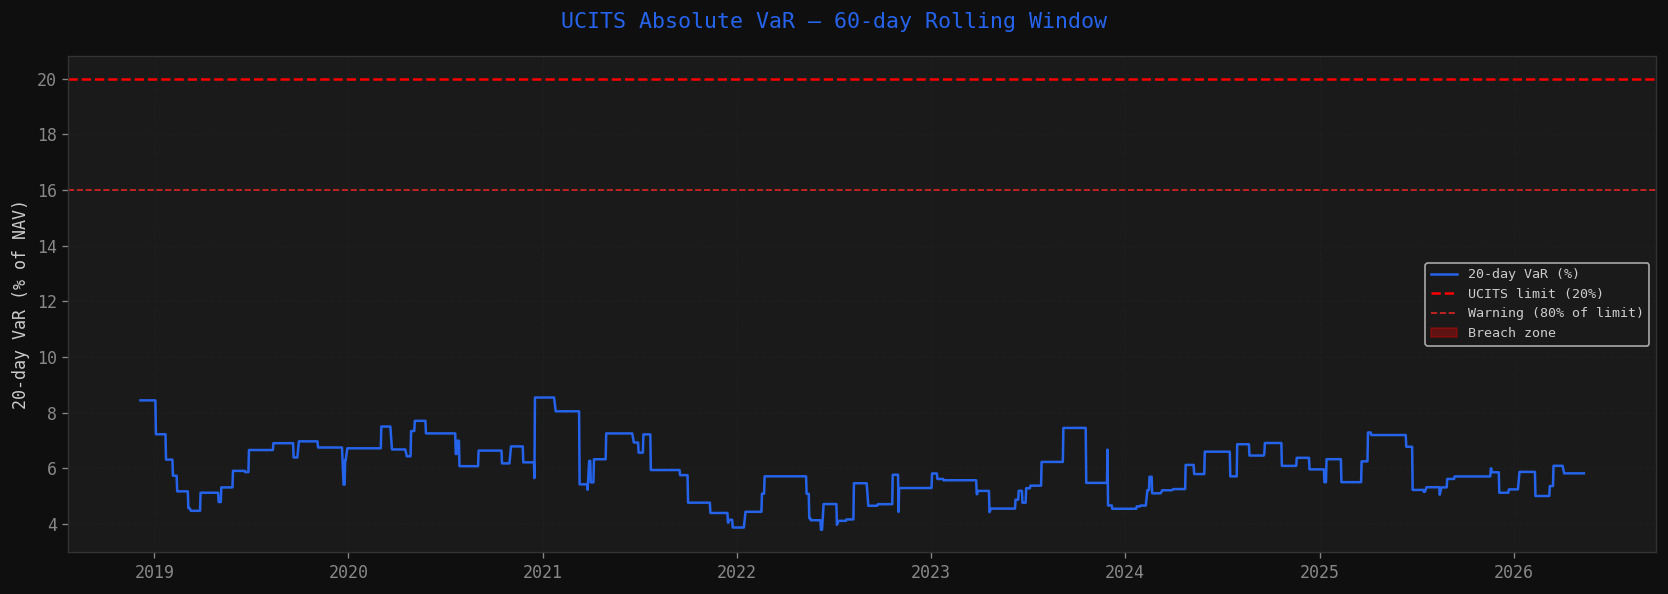

In [7]:
# ----------------------------------------------------------------
# Absolute VaR computation
# ----------------------------------------------------------------

# get P&L history from NAV
nav_history = query_nav_history(ENGINE, FUND_ID)
pnl         = nav_history['pnl_pct'].dropna().values

print(f'P&L history: {len(pnl)} daily observations')
print(f'Mean daily return : {pnl.mean()*100:.4f}%')
print(f'Daily volatility  : {pnl.std()*100:.4f}%')
print(f'Ann. volatility   : {pnl.std()*np.sqrt(252)*100:.2f}%')

# --- Historical simulation VaR ---
var_hist_1d  = var_historical(pnl, confidence=CONFIDENCE)
var_hist_20d = var_scale(var_hist_1d, horizon=HORIZON)

# --- Parametric VaR (Student-t) ---
mu           = pnl.mean()
sigma        = pnl.std()
var_para_1d  = var_parametric(mu=mu, sigma=sigma,
                               confidence=CONFIDENCE, dist='t', df=5)
var_para_20d = var_scale(var_para_1d, horizon=HORIZON)


print(f'\n--- VaR results ---')
print(f'{"Method":<20} {"1-day":>10} {"20-day":>10} '
      f'{"Limit":>10} {"Utilization":>12} {"Status":>8}')
print('-' * 75)

for method, var_1d, var_20d in [
    ('Historical',  var_hist_1d,  var_hist_20d),
    ('Parametric',  var_para_1d,  var_para_20d),
]:
    utilization = var_20d / VAR_LIMIT_ABS * 100
    status      = ('🔴 BREACH' if var_20d > VAR_LIMIT_ABS else
                   # 80% threshold for warning zone = var 16%+
                   '🟡 WARNING' if var_20d > VAR_LIMIT_ABS * 0.80 else
                   '🟢 OK')
    print(f'{method:<20} {var_1d*100:>9.3f}% {var_20d*100:>9.3f}% '
          f'{VAR_LIMIT_ABS*100:>9.0f}% {utilization:>11.1f}% {status:>8}')



# ----------------------------------------------------------------
# Rolling VaR chart
# ----------------------------------------------------------------
window   = 60
rolling_var = pd.Series([
    var_historical(pnl[max(0, i-window):i], confidence=CONFIDENCE)
    for i in range(window, len(pnl)+1)
])
dates_plot = nav_history['date'].iloc[window:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('UCITS Absolute VaR — 60-day Rolling Window',
             fontsize=13, color=ACCENT)

ax.plot(dates_plot, rolling_var * np.sqrt(HORIZON) * 100,
        color=ACCENT, lw=1.5, label='20-day VaR (%)')
ax.axhline(VAR_LIMIT_ABS * 100, color='red', lw=1.5,
           ls='--', label=f'UCITS limit ({VAR_LIMIT_ABS*100:.0f}%)')
ax.axhline(VAR_LIMIT_ABS * 80, color=ACCENT2, lw=1,
           ls='--', label='Warning (80% of limit)')
ax.fill_between(dates_plot,
                rolling_var * np.sqrt(HORIZON) * 100,
                VAR_LIMIT_ABS * 100,
                where=rolling_var * np.sqrt(HORIZON) > VAR_LIMIT_ABS,
                color='red', alpha=0.3, label='Breach zone')
ax.set_ylabel('20-day VaR (% of NAV)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The rolling VaR chart below is for internal monitoring only.
The single regulatory VaR figure computed from the full 250-day
window is what is reported to the CSSF. The rolling chart shows
how the risk profile has evolved over time, making gradual
increases in portfolio risk visible before they become a
regulatory concern.

## 3. Expected Shortfall (ES)
**Expected Shortfall (ES)** measures the average loss in the worst
scenarios beyond the VaR threshold. It is teh conditional expected loss when VAR is breached.

$$ES_{\alpha} = -\mathbb{E}[R \mid R < -VaR_{\alpha}]$$

For UCITS reporting, historical ES is the standard. Parametric ES
under the Student-t distribution:

$$ES_{\alpha} = \sigma \cdot \frac{f_t(t_{\alpha}) \cdot (\nu + t_{\alpha}^2)}{(\nu - 1)(1 - \alpha)}$$

is shown below for completeness. Parametric ES is not required by UCITS or AIFMD regulation and is more commonly encountered in the banking context under Basel IV, where Expected Shortfall at 97.5% replaced VaR as the primary capital measure under FRTB.

In [8]:
# --- ES ---
es_hist_1d   = es_historical(pnl, confidence=CONFIDENCE)
es_hist_20d  = es_scale(es_hist_1d, horizon=HORIZON)

# ----------------------------------------------------------------
# Expected Shortfall: parametric (Student-t) for completeness
# ----------------------------------------------------------------

es_para_1d  = es_parametric(sigma=sigma, mu=mu,
                             confidence=CONFIDENCE, dist='t', df=5)
es_para_20d = es_scale(es_para_1d, horizon=HORIZON)

print('--- Expected Shortfall comparison ---')
print(f'{"Method":<20} {"ES 1-day":>10} {"ES 20-day":>10} {"ES/VaR":>8}')
print('-' * 52)
print(f'{"Historical":<20} {es_hist_1d*100:>9.3f}% '
      f'{es_hist_20d*100:>9.3f}% '
      f'{es_hist_1d/var_hist_1d:>7.2f}x')
print(f'{"Parametric (t)":<20} {es_para_1d*100:>9.3f}% '
      f'{es_para_20d*100:>9.3f}% '
      f'{es_para_1d/var_para_1d:>7.2f}x')

print(f'\nNote: ES > VaR always holds by construction.')
print(f'ES/VaR ratio reflects tail heaviness: '
      f'higher ratio = fatter tails.')

--- Expected Shortfall comparison ---
Method                 ES 1-day  ES 20-day   ES/VaR
----------------------------------------------------
Historical               1.712%     7.655%    1.15x
Parametric (t)           2.935%    13.126%    1.32x

Note: ES > VaR always holds by construction.
ES/VaR ratio reflects tail heaviness: higher ratio = fatter tails.


## 4. Relative VaR

The UCITS relative VaR limit requires that the fund VaR does not
exceed **2x the VaR of the reference portfolio**. This approach
is used when the fund has a clear benchmark and is more appropriate
than the absolute limit for funds whose risk profile is defined
relative to a market index.

$$\text{Relative VaR} = \frac{VaR_{fund}}{VaR_{reference}} \leq 2$$

The reference portfolio for UCITS Balanced is a standard 60/40
allocation: 60% MSCI World (proxied by SPY) and 40% EUR government
bonds (proxied by IEAG, iShares Core EUR Govt Bond ETF). This is
documented in the fund's risk management policy and approved by
the CSSF.

Reference portfolio: 60% SPY + 40% TLT
Reference history  : 261 days
Reference daily vol: 1.0590%
Fund daily vol     : 0.6579%

--- Relative VaR ---
Fund VaR 20d      : 6.644%
Reference VaR 20d : 9.913%
Relative VaR ratio: 0.67x (limit: 2x)  🟢 OK
Utilization       : 33.5% of limit


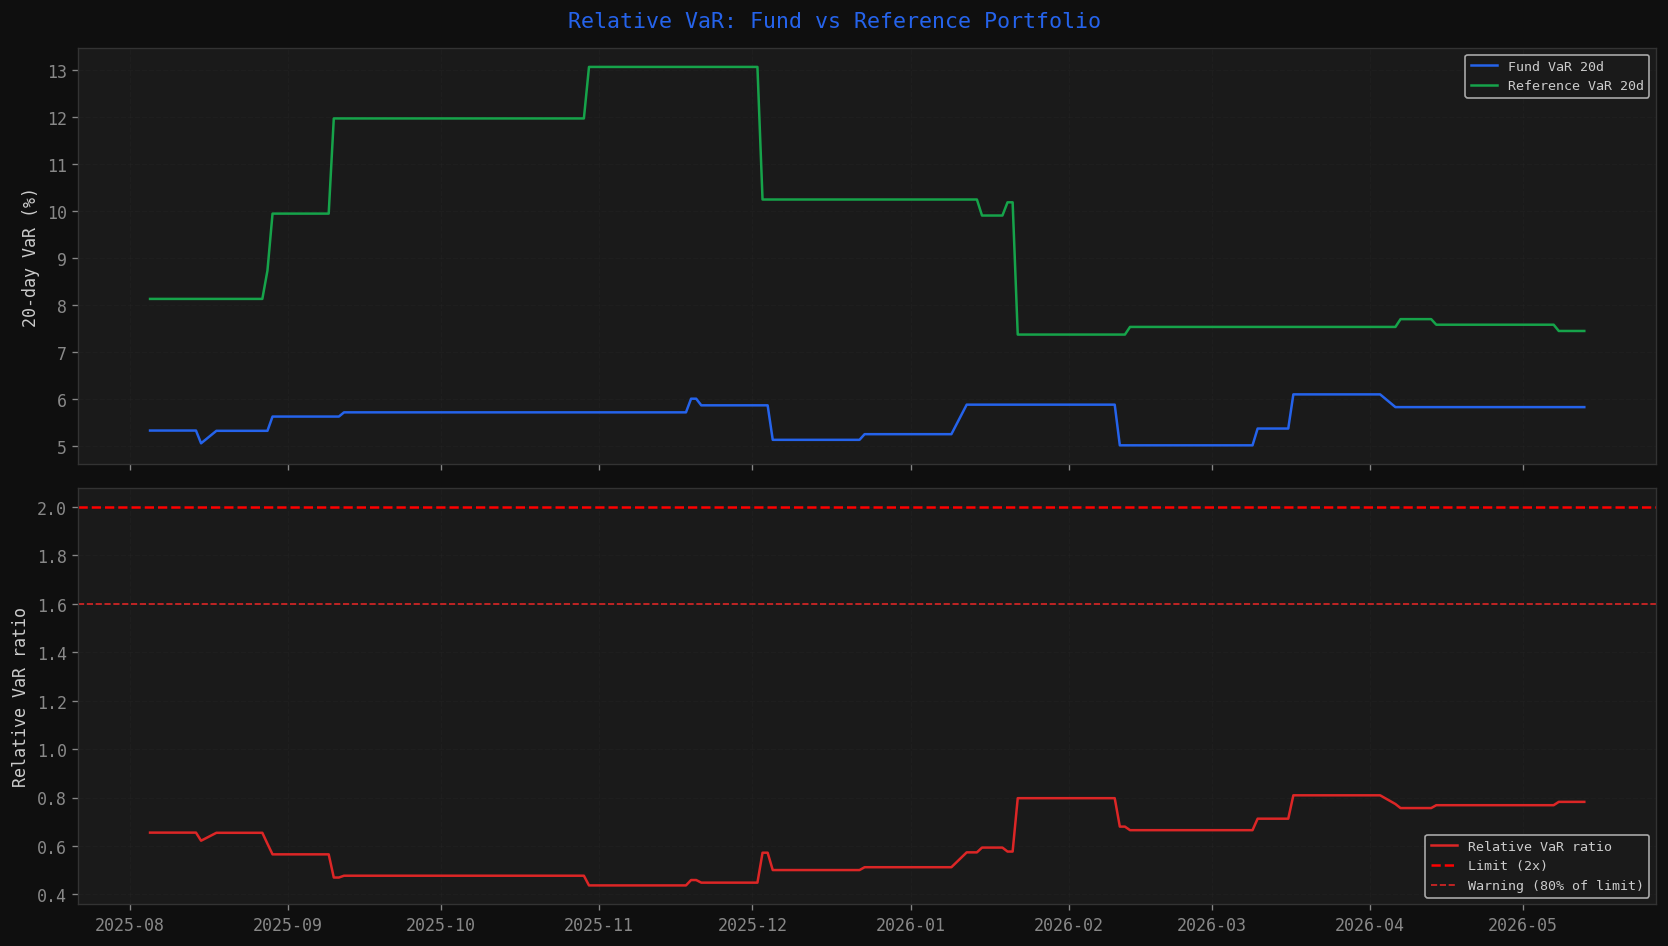

In [9]:
# ----------------------------------------------------------------
# Relative VaR
# ----------------------------------------------------------------

# reference portfolio: 60% SPY, 40% TLT
# reference portfolio: 60% SPY (MSCI World proxy), 40% IEAG (EUR Govt Bond proxy)
w_eq  = 0.60
w_bd  = 0.40

spy_hist  = BBG.bdh('SPY US Equity', 'PX_LAST', '2025-05-13', TODAY)
ieag_hist = BBG.bdh('IEAG LN Equity', 'PX_LAST', '2025-05-13', TODAY)

spy_ret  = spy_hist['PX_LAST'].pct_change().dropna()
ieag_ret = ieag_hist['PX_LAST'].pct_change().dropna()

ref_ret = (w_eq * spy_ret + w_bd * ieag_ret).dropna().values

print(f'Reference portfolio: {w_eq*100:.0f}% SPY + {w_bd*100:.0f}% TLT')
print(f'Reference history  : {len(ref_ret)} days')
print(f'Reference daily vol: {ref_ret.std()*100:.4f}%')
print(f'Fund daily vol     : {pnl.std()*100:.4f}%')

# VaR for reference portfolio
var_ref_1d  = var_historical(ref_ret, confidence=CONFIDENCE)
var_ref_20d = var_scale(var_ref_1d, horizon=HORIZON)

# relative VaR ratio
relative_var = var_hist_20d / var_ref_20d
status       = ('🔴 BREACH' if relative_var > VAR_LIMIT_REL else
                '🟡 WARNING' if relative_var > VAR_LIMIT_REL * 0.80 else
                '🟢 OK')

print(f'\n--- Relative VaR ---')
print(f'Fund VaR 20d      : {var_hist_20d*100:.3f}%')
print(f'Reference VaR 20d : {var_ref_20d*100:.3f}%')
print(f'Relative VaR ratio: {relative_var:.2f}x '
      f'(limit: {VAR_LIMIT_REL:.0f}x)  {status}')
print(f'Utilization       : {relative_var/VAR_LIMIT_REL*100:.1f}% of limit')

# ----------------------------------------------------------------
# Chart: fund vs reference portfolio rolling VaR
# ----------------------------------------------------------------
window = 60
min_len = min(len(pnl), len(ref_ret))
pnl_aligned = pnl[-min_len:]
ref_aligned = ref_ret[-min_len:]

rolling_var_fund = pd.Series([
    var_historical(pnl_aligned[max(0,i-window):i], CONFIDENCE)
    for i in range(window, min_len+1)
])
rolling_var_ref = pd.Series([
    var_historical(ref_aligned[max(0,i-window):i], CONFIDENCE)
    for i in range(window, min_len+1)
])
rolling_ratio = rolling_var_fund / rolling_var_ref

# dates_rel     = nav_history['date'].iloc[window:].reset_index(drop=True)
dates_rel = nav_history['date'].iloc[-len(rolling_var_fund):].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Relative VaR: Fund vs Reference Portfolio',
             fontsize=13, color=ACCENT)

axes[0].plot(dates_rel, rolling_var_fund * np.sqrt(HORIZON) * 100,
             color=ACCENT, lw=1.5, label='Fund VaR 20d')
axes[0].plot(dates_rel, rolling_var_ref * np.sqrt(HORIZON) * 100,
             color=ACCENT3, lw=1.5, label='Reference VaR 20d')
axes[0].set_ylabel('20-day VaR (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates_rel, rolling_ratio,
             color=ACCENT2, lw=1.5, label='Relative VaR ratio')
axes[1].axhline(VAR_LIMIT_REL, color='red', lw=1.5,
                ls='--', label=f'Limit ({VAR_LIMIT_REL:.0f}x)')
axes[1].axhline(VAR_LIMIT_REL * 0.80, color=ACCENT2, lw=1,
                ls='--', label='Warning (80% of limit)')
axes[1].set_ylabel('Relative VaR ratio')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. SRRI Computation
The SRRI (Synthetic Risk and Reward Indicator) is computed from 5 years of weekly NAV returns,
annualised, and mapped to a 1–7 category per CESR/10-673.

CESR/10-673 is the guidelines document published by the Committee of European Securities Regulators (the predecessor to ESMA) that defines exactly how to compute the SRRI. It specifies 
* the 5-year weekly return window
* the annualisation formula
* seven volatility buckets that map to categories 1 through 7. 

It is the regulatory basis for the risk indicator shown on every UCITS KIID.

| SRRI | Volatility range |
|------|-----------------|
| 1    | < 0.5%          |
| 2    | 0.5% – 2%       |
| 3    | 2% – 5%         |
| 4    | 5% – 10%        |
| 5    | 10% – 15%       |
| 6    | 15% – 25%       |
| 7    | >= 25%          |

In [10]:
# MRS-41: SRRI computation (CESR/10-673)
nav_history_full = query_nav_history(ENGINE, FUND_ID)
nav_history_full['date'] = pd.to_datetime(nav_history_full['date'])
nav_history_full = nav_history_full.set_index('date')

# CESR/10-673 mandates exactly 260 weekly observations (5 years)
# last('260W') was removed in pandas 2.0; use explicit date filter instead
cutoff = nav_history_full.index.max() - pd.DateOffset(weeks=260)
nav_history_5y = nav_history_full[nav_history_full.index >= cutoff]

weekly_nav = nav_history_5y['nav_eur'].resample('W').last()
weekly_ret = weekly_nav.pct_change().dropna()
sigma_weekly = weekly_ret.std()
sigma_ann = sigma_weekly * np.sqrt(52)

def compute_srri(sigma_ann: float) -> int:
    """Map annualised volatility to SRRI category per CESR/10-673 Table 1.

    Boundaries: 1:<0.5%, 2:0.5-2%, 3:2-5%, 4:5-10%, 5:10-15%, 6:15-25%, 7:>=25%
    """
    boundaries = [0, 0.005, 0.02, 0.05, 0.10, 0.15, 0.25]
    for i, bound in enumerate(boundaries):
        if sigma_ann <= bound:
            return i
    return 7

srri = compute_srri(sigma_ann)

print(f"Weekly return observations : {len(weekly_ret)}")
print(f"Annualised volatility      : {sigma_ann * 100:.2f}%")
print(f"SRRI category              : {srri}")

Weekly return observations : 260
Annualised volatility      : 9.54%
SRRI category              : 4


## 6. UCITS Stress Testing

UCITS regulations (2009/65/EC and ESMA guidelines) require stress testing but do not
prescribe specific scenario parameters. Shocks below are defined in the fund's Risk
Management Policy (RMP) and approved by the board.

Scenarios covered:
- **Equity crash**: equity down 30%
- **Rate shock**: parallel shift up 200bps
- **Credit widening**: credit spreads widen 150bps
- **FX stress**: USD/GBP depreciate 15% vs EUR
- **Combined**: simultaneous equity, rate, credit and FX shock
- **Historical**: 2008 financial crisis, 2020 COVID crash, 2022 rate shock

In [11]:
# MRS-42: stress testing setup
risk_df = get_risk_ready_df(ENGINE, FUND_ID, TODAY)
NAV     = risk_df['market_value_eur'].sum()

ACCENT  = '#2563EB'
ACCENT2 = '#DC2626'
ACCENT3 = '#16A34A'

In [12]:
# Equity crash: -30%
eq = stress_equity(risk_df, delta_equity=-0.30)
eq_pct = eq['stressed_pnl_eur'] / NAV * 100

# Rate shock: +200bps
rt = stress_rates(risk_df, delta_y=0.02)
rt_pct = rt['stressed_pnl_eur'] / NAV * 100

# Credit widening: +150bps
cr = stress_credit(risk_df, delta_spread=0.015)
cr_pct = cr['stressed_pnl_eur'] / NAV * 100

# FX stress: USD and GBP depreciate 15% vs EUR
fx = stress_fx(risk_df, fx_shocks={'USD': -0.15, 'GBP': -0.15})
fx_pct = fx['stressed_pnl_eur'] / NAV * 100

summary = pd.DataFrame([
    {'Scenario': 'Equity Crash -30%',      'P&L (EUR)': eq['stressed_pnl_eur'], '% NAV': eq_pct},
    {'Scenario': 'Rate Shock +200bps',     'P&L (EUR)': rt['stressed_pnl_eur'], '% NAV': rt_pct},
    {'Scenario': 'Credit Widening +150bps','P&L (EUR)': cr['stressed_pnl_eur'], '% NAV': cr_pct},
    {'Scenario': 'FX Stress USD/GBP -15%', 'P&L (EUR)': fx['stressed_pnl_eur'], '% NAV': fx_pct},
])

summary['P&L (EUR)'] = summary['P&L (EUR)'].map('{:,.0f}'.format)
summary['% NAV']     = summary['% NAV'].map('{:.2f}%'.format)
summary.set_index('Scenario', inplace=True)
summary

,P&L (EUR),% NAV
Scenario,,
Equity Crash -30%,"-89,921,476",-21.86%
Rate Shock +200bps,"-4,782,031",-1.16%
Credit Widening +150bps,"-1,121,069",-0.27%
FX Stress USD/GBP -15%,"-30,101,293",-7.32%


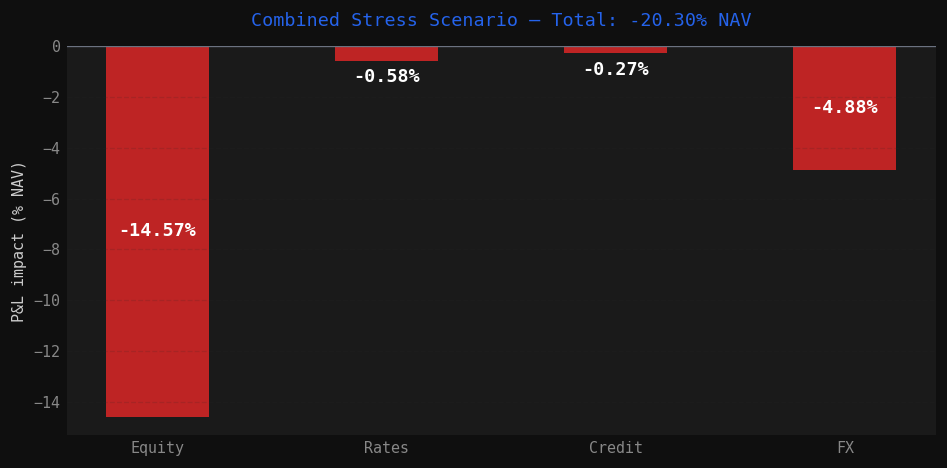

Combined stress P&L: EUR -83,527,839  (-20.30% NAV)


In [13]:
# Combined scenario
cb = stress_combined(risk_df)
cb_pct = cb['stressed_pnl_eur'] / NAV * 100

components = {
    'Equity': cb['equity_pnl'] / NAV * 100,
    'Rates':  cb['rates_pnl']  / NAV * 100,
    'Credit': cb['credit_pnl'] / NAV * 100,
    'FX':     cb['fx_pnl']     / NAV * 100,
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(components.keys(), components.values(),
              color=[ACCENT2 if v < 0 else ACCENT3 for v in components.values()],
              width=0.45, alpha=0.85)
ax.axhline(0, color='#6b7280', lw=0.8)
ax.set_ylabel('P&L impact (% NAV)', fontsize=9)
ax.set_title(f'Combined Stress Scenario — Total: {cb_pct:.2f}% NAV', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, components.values()):
    if abs(val) < 2:
        ax.text(bar.get_x() + bar.get_width()/2,
                val - 0.3,
                f'{val:.2f}%',
                ha='center', va='top',
                fontsize=11, color='white', fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2,
                val / 2,
                f'{val:.2f}%',
                ha='center', va='center',
                fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Combined stress P&L: EUR {cb['stressed_pnl_eur']:,.0f}  ({cb_pct:.2f}% NAV)")

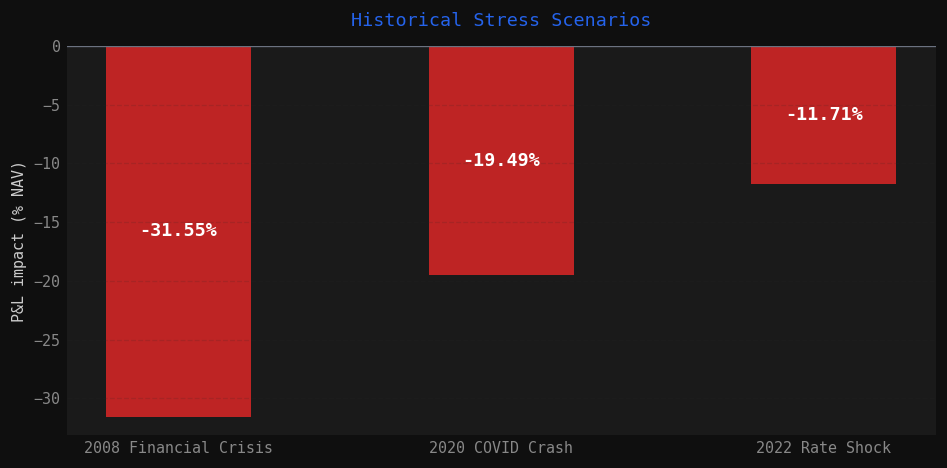

2008 Financial Crisis         : EUR    -129,778,461  (-31.55% NAV)
2020 COVID Crash              : EUR     -80,186,243  (-19.49% NAV)
2022 Rate Shock               : EUR     -48,172,510  (-11.71% NAV)


In [14]:
# Historical scenarios: 2008, 2020, 2022
scenarios = ['2008', '2020', '2022']
labels    = ['2008 Financial Crisis', '2020 COVID Crash', '2022 Rate Shock']
results   = [stress_historical(risk_df, s) for s in scenarios]
pnls_pct  = [r['stressed_pnl_eur'] / NAV * 100 for r in results]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, pnls_pct,
              color=[ACCENT2 if v < 0 else ACCENT3 for v in pnls_pct],
              width=0.45, alpha=0.85)
ax.axhline(0, color='#6b7280', lw=0.8)
ax.set_ylabel('P&L impact (% NAV)', fontsize=9)
ax.set_title('Historical Stress Scenarios', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, pnls_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            val / 2,
            f'{val:.2f}%',
            ha='center', va='center',
            fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

for label, r, pct in zip(labels, results, pnls_pct):
    print(f"{label:30s}: EUR {r['stressed_pnl_eur']:>15,.0f}  ({pct:.2f}% NAV)")

> **Methodology note**: stress P&L is computed using first-order sensitivities
> (delta for equities, modified duration for rates and credit, direct revaluation for FX).
> Convexity and cross-gamma effects are not captured. In production, a ManCo would
> source these figures from a risk system (Bloomberg PORT, Aladdin, Axioma) which
> performs full revaluation. Results here should be read as directional estimates.

## 7. VaR Backtest (Kupiec + Christoffersen + ESMA)

VaR backtesting compares predicted VaR against realised daily P&L.
Two statistical tests are applied:

- **Kupiec POF**: tests whether the breach rate equals the expected rate (1% for 99% VaR)
- **Christoffersen**: tests whether breaches are independently distributed over time

> **Note**: Kupiec and Christoffersen tests are industry best practice and not explicitly
> required by ESMA or CSSF. The regulatory requirement is the 250-day breach count
> and zone classification only. Both tests should be documented in the RMP. For both models 
> p > 0.05: fail to reject the null, model is statistically acceptable

ESMA (CESR/10-788) requires backtesting 1-day 99% VaR against realised daily P&L
over a 250 trading day rolling window. Both historical and parametric VaR are acceptable;
historical simulation is preferred in practice as it makes no distributional assumptions
and is easier to justify to the CSSF.

Zone classification (Basel traffic light, adopted by ESMA):
- **Green** (0-4 breaches): model acceptable
- **Amber** (5-9 breaches): explanation required, possible model review
- **Red** (10+ breaches): model must be revised, CSSF notification required

>Note: POF=Proportion of Failures. It tests whether the observed breach rate (number of days P&L exceeded VaR divided by total observations) is statistically consistent with the expected rate (1% for 99% VaR). It is a likelihood ratio test.

#### 7.1. Internal usage: full period

In [15]:
# MRS-43: VaR backtest
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])

pnl    = nav_history['pnl_pct'].dropna().values
dates  = nav_history['date'].iloc[1:].reset_index(drop=True)

# compute rolling 1-day VaR series (250-day window)
window = 250
var_hist  = pd.Series([
    var_historical(pnl[max(0, i-window):i], confidence=0.99)
    for i in range(window, len(pnl))
])
var_param = pd.Series([
    var_parametric(mu=0, sigma=pnl[max(0, i-window):i].std(),
                   confidence=0.99, dist='t')
    for i in range(window, len(pnl))
])

pnl_aligned   = pnl[window:]
dates_aligned = dates.iloc[window:].reset_index(drop=True)

print(f"Backtest observations : {len(pnl_aligned)}")

Backtest observations : 1749


In [16]:
report = full_backtest_report(
    pnl_series=pd.Series(pnl_aligned),
    var_dict={'Historical': var_hist, 'Parametric': var_param},
    dates=dates_aligned
)

report[['n_obs', 'n_breaches', 'breach_rate', 'expected',
        'kupiec_p', 'christoffersen_p', 'result']]

,n_obs,n_breaches,breach_rate,expected,kupiec_p,christoffersen_p,result
0,1749,19,0.0109,0.010,0.7204,0.5181,PASS
1,1749,19,0.0109,0.025,0.0000,0.5181,FAIL
2,1749,19,0.0109,0.050,0.0000,0.5181,FAIL
3,1749,1,0.0006,0.010,0.0000,0.9730,FAIL
4,1749,1,0.0006,0.025,0.0000,0.9730,FAIL
5,1749,1,0.0006,0.050,0.0000,0.9730,FAIL


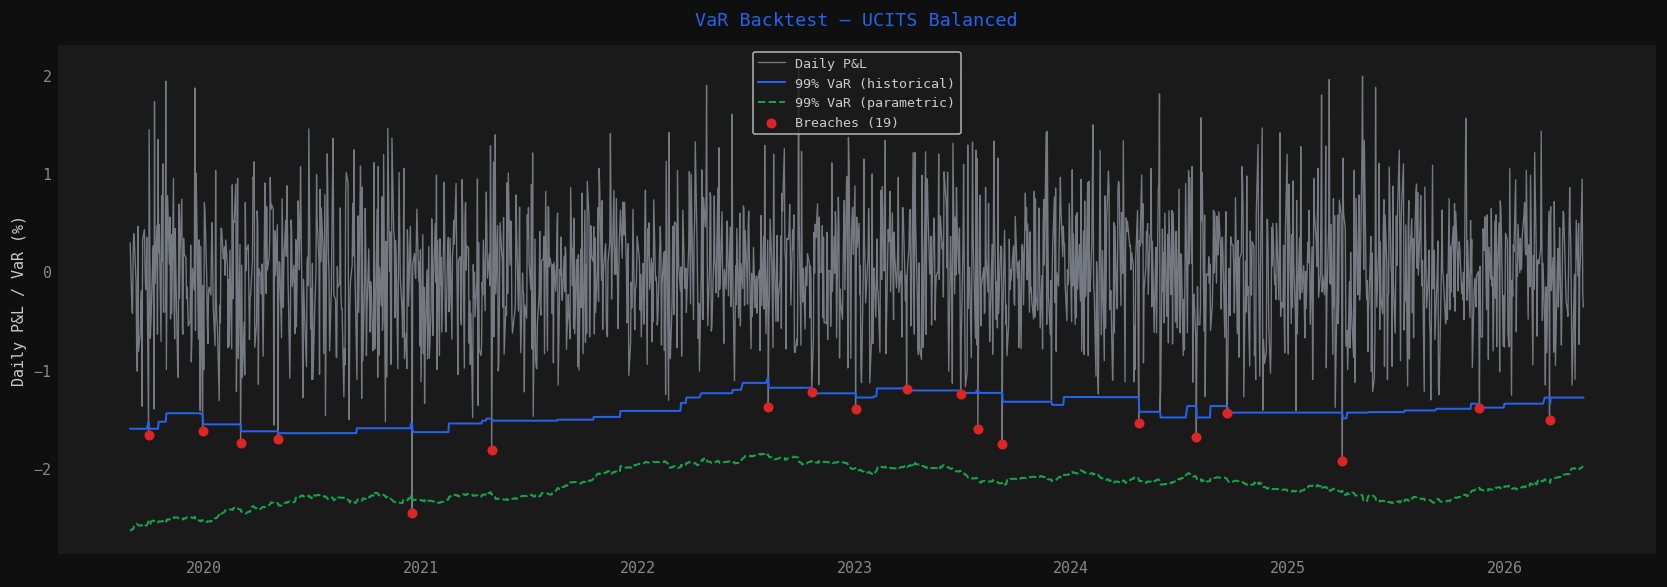

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_aligned, pnl_aligned * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_aligned, -var_hist * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')
ax.plot(dates_aligned, -var_param * 100,
        color=ACCENT3, lw=1.2, label='99% VaR (parametric)', linestyle='--')

breaches = pnl_aligned < -var_hist.values
ax.scatter(dates_aligned[breaches], pnl_aligned[breaches] * 100,
           color=ACCENT2, s=25, zorder=5, label=f'Breaches ({breaches.sum()})')

ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.set_title('VaR Backtest — UCITS Balanced', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### 7.2. ESMA report 250 days

In [18]:
# ESMA exception report: last 250 trading days (regulatory window)
esma_250    = exception_report(pd.Series(pnl_aligned[-250:]), var_hist.iloc[-250:], confidence=0.99)
n_250       = len(esma_250)
breach_250  = n_250 / 250

if n_250 <= 4:
    zone_250 = 'Green'
elif n_250 <= 9:
    zone_250 = 'Amber'
else:
    zone_250 = 'Red'

print(f"ESMA regulatory window (last 250 trading days)")
print(f"Breaches          : {n_250}")
print(f"Breach rate       : {breach_250*100:.2f}% (expected 1.0%)")
print(f"ESMA zone         : {zone_250}")
print()
esma_250

Exception report (99% VaR):
  observations : 250
  breaches     : 2
  breach rate  : 0.80% (expected 1.0%)
  action       : Model acceptable
ESMA regulatory window (last 250 trading days)
Breaches          : 2
Breach rate       : 0.80% (expected 1.0%)
ESMA zone         : Green



,date,pnl,var,excess_loss,action
0,124,-0.013905,0.013475,0.000431,Model acceptable
1,208,-0.015097,0.012856,0.002241,Model acceptable


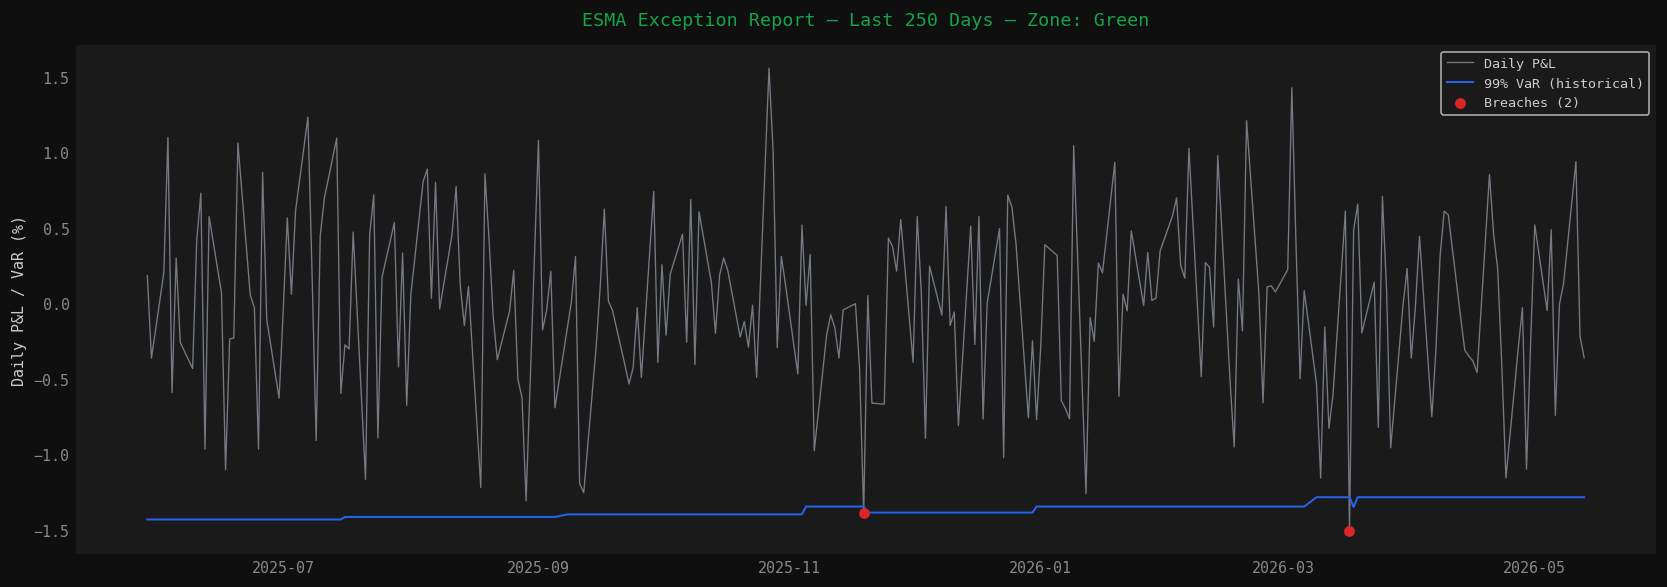

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

dates_250 = dates_aligned.iloc[-250:].reset_index(drop=True)
pnl_250   = pnl_aligned[-250:]
var_250   = var_hist.iloc[-250:].reset_index(drop=True)

ax.plot(dates_250, pnl_250 * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_250, -var_250 * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')

breaches_250 = pnl_250 < -var_250.values
ax.scatter(dates_250[breaches_250], pnl_250[breaches_250] * 100,
           color=ACCENT2, s=30, zorder=5, label=f'Breaches ({n_250})')

zone_color = {'Green': '#16A34A', 'Amber': '#D97706', 'Red': '#DC2626'}
ax.set_title(f'ESMA Exception Report — Last 250 Days — Zone: {zone_250}',
             color=zone_color[zone_250], fontsize=11, pad=12)
ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Absolute and Relative VaR Monitoring Report

In [20]:
# MRS-44: VaR monitoring report
from src.risk_utils import var_scale

# --- Absolute VaR ---
pnl_1y        = pnl[-250:]
abs_var_1d    = var_historical(pnl_1y, confidence=0.99)
abs_var_20d   = var_scale(abs_var_1d, horizon=20) * 100  # % NAV
abs_limit     = 20.0
abs_util      = abs_var_20d / abs_limit * 100

# --- Relative VaR ---
rel_var_current = rolling_ratio.iloc[-1] if len(rolling_ratio) > 0 else None
rel_limit       = 2.0
rel_util        = rel_var_current / rel_limit * 100

# --- Summary table ---
summary = pd.DataFrame([
    {'Metric': 'Absolute VaR (20d 99%)',    'Value': f'{abs_var_20d:.2f}%',       'Limit': '20.00%',  'Utilisation': f'{abs_util:.1f}%',  'Status': 'OK' if abs_var_20d < abs_limit else 'BREACH'},
    {'Metric': 'Relative VaR (ratio)',       'Value': f'{rel_var_current:.2f}x',   'Limit': '2.00x',   'Utilisation': f'{rel_util:.1f}%',  'Status': 'OK' if rel_var_current < rel_limit else 'BREACH'},
    {'Metric': 'SRRI',                       'Value': str(srri),                   'Limit': '—',       'Utilisation': '—',                 'Status': '—'},
    {'Metric': 'ESMA Zone (250d)',            'Value': zone_250,                    'Limit': 'Green',   'Utilisation': f'{n_250} breaches', 'Status': 'OK' if zone_250 == 'Green' else 'REVIEW'},
])
summary.set_index('Metric', inplace=True)
summary

,Value,Limit,Utilisation,Status
Metric,,,,
Absolute VaR (20d 99%),5.75%,20.00%,28.7%,OK
Relative VaR (ratio),0.78x,2.00x,39.1%,OK
SRRI,4,—,—,—
ESMA Zone (250d),Green,Green,2 breaches,OK


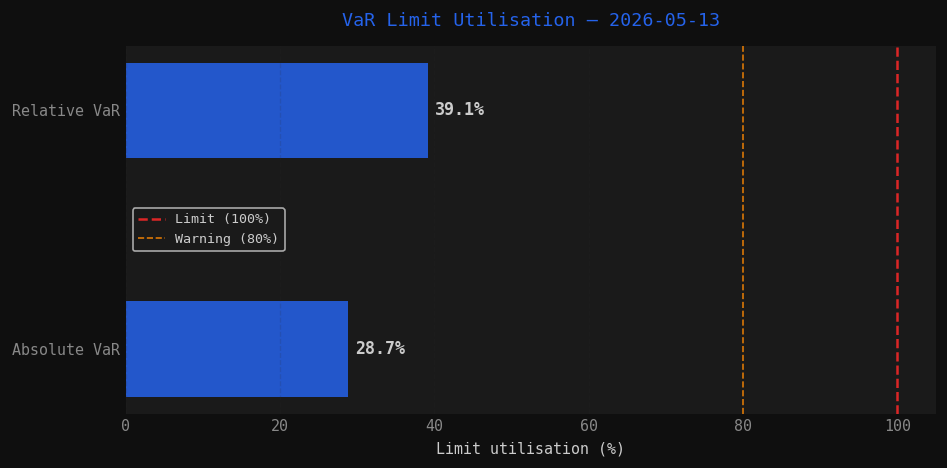

In [21]:
metrics  = ['Absolute VaR', 'Relative VaR']
utils    = [abs_util, rel_util]
colors   = [ACCENT2 if u > 80 else ACCENT3 if u > 60 else ACCENT for u in utils]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(metrics, utils, color=colors, height=0.4, alpha=0.85)
ax.axvline(100, color=ACCENT2, lw=1.5, linestyle='--', label='Limit (100%)')
ax.axvline(80,  color='#D97706', lw=1, linestyle='--', label='Warning (80%)')
ax.set_xlabel('Limit utilisation (%)', fontsize=9)
ax.set_title(f'VaR Limit Utilisation — {TODAY}', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='x', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
for bar, val in zip(bars, utils):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. SRRI Monitoring and KIID Update Trigger

CESR/10-673 requires ManCos to monitor SRRI continuously and update the KIID
if the SRRI changes category for 4 consecutive months. The rolling SRRI is
computed monthly using a trailing 260-week (5-year) window.

In [22]:
# MRS-45: SRRI monitoring
nav_history_full = query_nav_history(ENGINE, FUND_ID)
nav_history_full['date'] = pd.to_datetime(nav_history_full['date'])
nav_history_full = nav_history_full.set_index('date')

# resample to weekly, compute rolling 260-week SRRI monthly
weekly_nav_full = nav_history_full['nav_eur'].resample('W').last()
weekly_ret_full = weekly_nav_full.pct_change().dropna()

# compute SRRI at each month-end using trailing 260 weeks
monthly_ends = weekly_ret_full.resample('ME').last().index
rolling_srri = []

for dt in monthly_ends:
    window_ret = weekly_ret_full[:dt].iloc[-260:]
    if len(window_ret) < 52:
        continue
    sigma_w   = window_ret.std()
    sigma_a   = sigma_w * np.sqrt(52)
    rolling_srri.append({'date': dt, 'srri': compute_srri(sigma_a), 'sigma_ann': sigma_a})

srri_df = pd.DataFrame(rolling_srri).set_index('date')
print(f"Rolling SRRI observations : {len(srri_df)}")
srri_df.tail(6)

Rolling SRRI observations : 81


,srri,sigma_ann
date,,
2025-12-31,4,0.095470
2026-01-31,4,0.094880
2026-02-28,4,0.095590
2026-03-31,4,0.095998
2026-04-30,4,0.095732
2026-05-31,4,0.095398


In [23]:
# flag 4 consecutive months where SRRI stays at a new level
srri_df['srri_prev']     = srri_df['srri'].shift(1)
srri_df['changed']       = srri_df['srri'] != srri_df['srri_prev']

# count consecutive months at current SRRI vs initial SRRI
initial_srri             = srri_df['srri'].iloc[0]
srri_df['consec_new']    = 0

consec = 0
ref    = srri_df['srri'].iloc[0]
for idx, row in srri_df.iterrows():
    if row['srri'] != ref:
        consec += 1
    else:
        consec = 0
        ref    = row['srri']
    srri_df.at[idx, 'consec_new'] = consec

srri_df['kiid_update'] = srri_df['consec_new'] >= 4

n_triggers = srri_df['kiid_update'].sum()
print(f"KIID update triggers in history : {n_triggers}")
print(f"Current SRRI                    : {srri_df['srri'].iloc[-1]}")
print(f"KIID update required now        : {srri_df['kiid_update'].iloc[-1]}")

KIID update triggers in history : 26
Current SRRI                    : 4
KIID update required now        : True


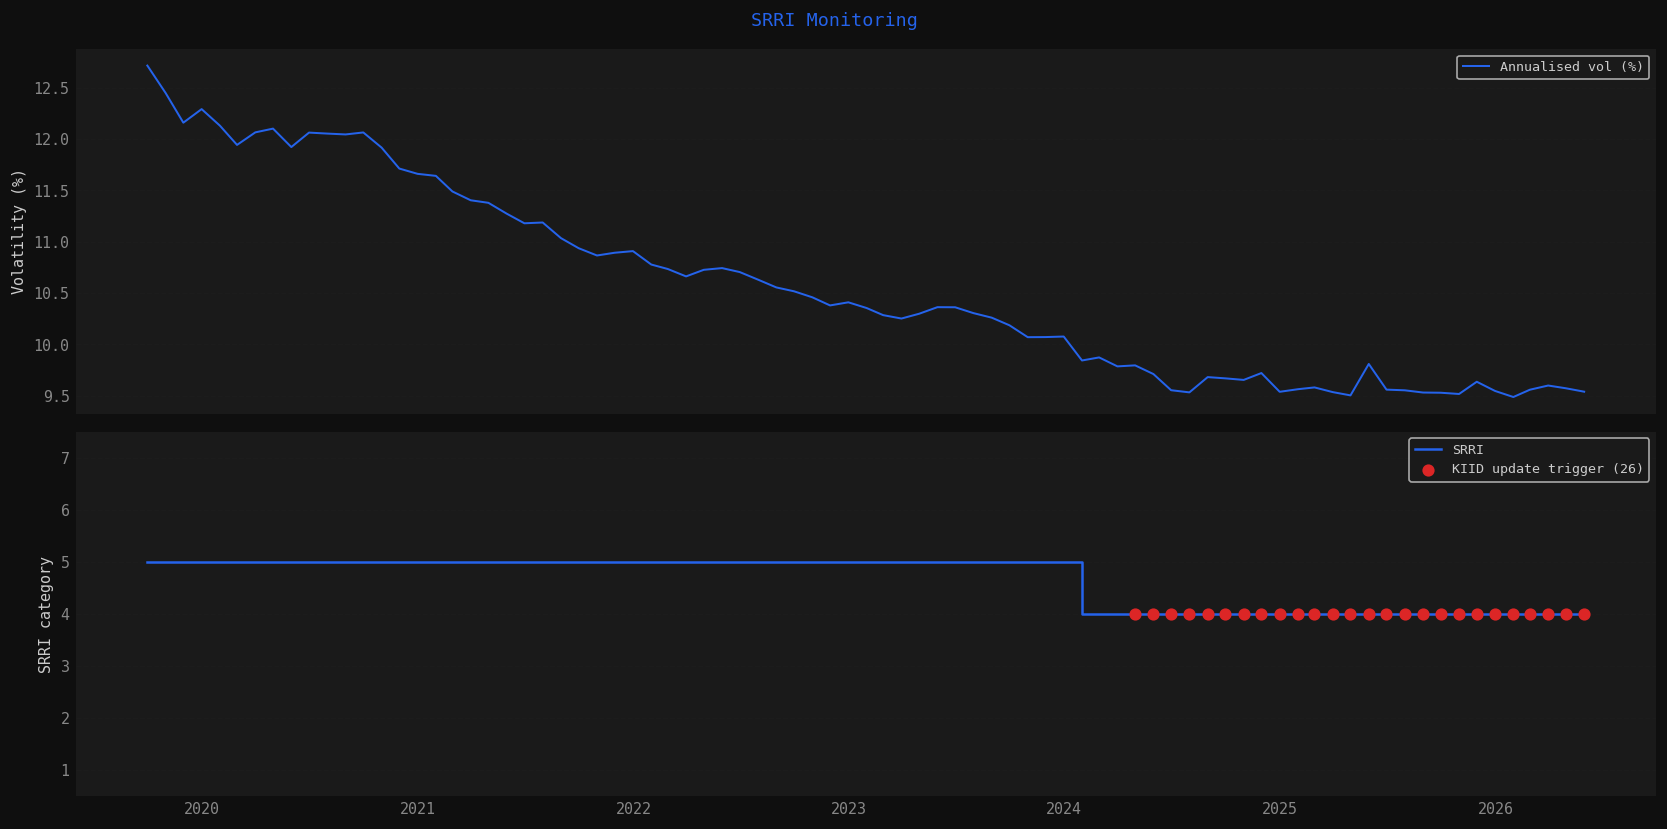

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('SRRI Monitoring', color=ACCENT, fontsize=11)

# top: rolling annualised volatility
axes[0].plot(srri_df.index, srri_df['sigma_ann'] * 100,
             color=ACCENT, lw=1.2, label='Annualised vol (%)')
axes[0].set_ylabel('Volatility (%)', fontsize=9)
axes[0].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[0].grid(True, axis='y', alpha=0.15, linestyle='--')
axes[0].tick_params(labelsize=9, length=0)
axes[0].legend(fontsize=8)

# bottom: rolling SRRI with KIID triggers
axes[1].step(srri_df.index, srri_df['srri'],
             color=ACCENT, lw=1.5, label='SRRI', where='post')
axes[1].set_yticks([1, 2, 3, 4, 5, 6, 7])
axes[1].set_ylim(0.5, 7.5)
axes[1].set_ylabel('SRRI category', fontsize=9)
axes[1].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[1].grid(True, axis='y', alpha=0.15, linestyle='--')
axes[1].tick_params(labelsize=9, length=0)

triggers = srri_df[srri_df['kiid_update']]
if len(triggers) > 0:
    axes[1].scatter(triggers.index, triggers['srri'],
                    color=ACCENT2, s=40, zorder=5,
                    label=f'KIID update trigger ({len(triggers)})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Monthly Risk Report

Summary risk report as of the most recent valuation date.
Produced monthly by the Risk Management function and reviewed by the Board.

In [25]:
# MRS-46: monthly risk report
from datetime import datetime

report_date = pd.Timestamp(TODAY).strftime('%B %d, %Y')
nav_eur     = risk_df['market_value_eur'].sum()

print('=' * 60)
print(f'  UCITS BALANCED FUND — MONTHLY RISK REPORT')
print(f'  Valuation date : {report_date}')
print(f'  NAV            : EUR {nav_eur:,.0f}')
print('=' * 60)

print('\n  1. VAR SUMMARY')
print('  ' + '-' * 40)
print(f'  Absolute VaR (20d 99%)  : {abs_var_20d:.2f}%   limit 20.00%   util {abs_util:.1f}%')
print(f'  Relative VaR (ratio)    : {rel_var_current:.2f}x     limit 2.00x     util {rel_util:.1f}%')
print(f'  VaR model               : Historical simulation, 250-day window')

print('\n  2. SRRI')
print('  ' + '-' * 40)
print(f'  Current SRRI            : {srri_df["srri"].iloc[-1]}')
print(f'  Annualised volatility   : {srri_df["sigma_ann"].iloc[-1]*100:.2f}%')
print(f'  KIID update required    : {"YES — action required" if srri_df["kiid_update"].iloc[-1] else "No"}')

print('\n  3. BACKTEST (ESMA)')
print('  ' + '-' * 40)
print(f'  Observation window      : 250 trading days')
print(f'  Breaches                : {n_250}')
print(f'  Expected breaches       : 2.5 (1% x 250)')
print(f'  ESMA zone               : {zone_250}')
print(f'  Kupiec p-value          : {report["kupiec_p"].iloc[0]:.4f}')
print(f'  Christoffersen p-value  : {report["christoffersen_p"].iloc[0]:.4f}')

print('\n  4. STRESS TESTING')
print('  ' + '-' * 40)
print(f'  Equity crash -30%       : {eq_pct:.2f}% NAV')
print(f'  Rate shock +200bps      : {rt_pct:.2f}% NAV')
print(f'  Credit widening +150bps : {cr_pct:.2f}% NAV')
print(f'  FX stress -15%          : {fx_pct:.2f}% NAV')
print(f'  Combined scenario       : {cb_pct:.2f}% NAV')
print(f'  2008 financial crisis   : {pnls_pct[0]:.2f}% NAV')
print(f'  2020 COVID crash        : {pnls_pct[1]:.2f}% NAV')
print(f'  2022 rate shock         : {pnls_pct[2]:.2f}% NAV')

print('\n  5. COMPLIANCE')
print('  ' + '-' * 40)
abs_status = 'COMPLIANT' if abs_var_20d < abs_limit else 'BREACH'
rel_status = 'COMPLIANT' if rel_var_current < rel_limit else 'BREACH'
print(f'  Absolute VaR limit      : {abs_status}')
print(f'  Relative VaR limit      : {rel_status}')
print(f'  ESMA backtest zone      : {zone_250}')
print(f'  UCITS eligible          : Yes')

print('\n' + '=' * 60)
print('  Prepared by  : Risk Management')
print(f'  Report date  : {datetime.today().strftime("%B %d, %Y")}')
print('=' * 60)

  UCITS BALANCED FUND — MONTHLY RISK REPORT
  Valuation date : May 13, 2026
  NAV            : EUR 411,372,681

  1. VAR SUMMARY
  ----------------------------------------
  Absolute VaR (20d 99%)  : 5.75%   limit 20.00%   util 28.7%
  Relative VaR (ratio)    : 0.78x     limit 2.00x     util 39.1%
  VaR model               : Historical simulation, 250-day window

  2. SRRI
  ----------------------------------------
  Current SRRI            : 4
  Annualised volatility   : 9.54%
  KIID update required    : YES — action required

  3. BACKTEST (ESMA)
  ----------------------------------------
  Observation window      : 250 trading days
  Breaches                : 2
  Expected breaches       : 2.5 (1% x 250)
  ESMA zone               : Green
  Kupiec p-value          : 0.7204
  Christoffersen p-value  : 0.5181

  4. STRESS TESTING
  ----------------------------------------
  Equity crash -30%       : -21.86% NAV
  Rate shock +200bps      : -1.16% NAV
  Credit widening +150bps : -0.27% NA

## ESG Risk Indicators

ESG monitoring is required under CSSF Regulation 22-05 and SFDR (EU 2019/2088).
Portfolio-level ESG scores are computed as NAV-weighted averages. 

**SFDR classification**: Article 6 (no sustainability claim). ESG factors are
monitored but do not drive investment decisions. Article 8 would require documented
ESG screening; Article 9 would require sustainable investment as the primary objective.

Metrics monitored:
- Weighted average ESG score (composite, E, S, G)
- % of NAV in instruments with ESG score below 30*
- % of NAV with active controversy flag
- Weighted average carbon intensity (tCO2/EURm revenue)

> **Note**: ESG scores for liquid instruments are fetched from Bloomberg at
> enrichment time. Instruments without a Bloomberg ticker use fund administrator
> ESG data embedded in the position file.


> % of NAV in instruments with ESG score below internal threshold. 
> Threshold is defined in the Risk Management Policy. 
> ESG scores are not comparable across providers as each
> uses a different methodology and scale.
> (here using 30/100,Bloomberg scale 0-100 higher is better)

> **Scale note**: all ESG scores in this framework use a 0-100 scale where
> 100 is best, consistent with Bloomberg ESG methodology. Illiquid instrument
> scores are provided by the fund administrator on the same scale. In production,
> the ManCo should ensure all third-party ESG data is normalised to a consistent
> scale before aggregating portfolio-level metrics.

> **ESG look-through for derivatives**: derivatives have indirect ESG exposure
> through their underlying. The delta-adjusted notional is used as the ESG
> exposure weight rather than market value, which would understate the exposure.
>
> For options:
> $$ESG\_exposure_i = |\delta_i| \times Q_i \times \text{contract size} \times P_{underlying} \times FX$$

> For futures: full notional is used since delta = 1.
> For FX forwards: no ESG exposure assigned (no issuer).

In [26]:
esg_df  = build_esg_df(risk_df, BBG, ENGINE, FUND_ID, TODAY)
summary = esg_portfolio_summary(esg_df, NAV)

In [27]:
def style_esg(row):
    styles = [''] * len(row)
    idx = esg_df.columns.tolist()
    if row.get('controversy_flag') == True:
        return ['background-color: #7f1d1d; color: white'] * len(row)
    elif pd.notna(row.get('esg_score')) and row.get('esg_score') < ESG_THRESHOLD:
        styles[idx.index('esg_score')] = 'background-color: #7f1d1d; color: white'
    return styles

esg_df.style.apply(style_esg, axis=1).format({
    'market_value_eur' : '{:,.0f}',
    'weight_pct'       : '{:.2f}%',
    'esg_score'        : '{:.0f}',
    'env_score'        : '{:.0f}',
    'soc_score'        : '{:.0f}',
    'gov_score'        : '{:.0f}',
    'carbon_intensity' : '{:.1f}',
    'esg_exposure_eur' : '{:,.0f}',
}, na_rep='—')

,instrument_name,asset_class,sub_asset_class,market_value_eur,weight_pct,esg_score,env_score,soc_score,gov_score,controversy_flag,carbon_intensity,esg_exposure_eur
0,SPDR S&P 500 ETF,Equity,ETF,"174,691,425",42.47%,62,58,65,63,False,145.2,"174,691,425"
1,Euro Stoxx 50 ETF,Equity,ETF,"125,046,828",30.40%,64,61,66,65,False,168.4,"125,046,828"
2,DBR 0 08/15/29,Bond,Government,"40,891,500",9.94%,82,85,81,80,False,—,"40,891,500"
3,Cash EUR,Cash,Cash,"25,000,000",6.08%,—,—,—,—,—,—,0
4,SPDR Gold Shares,Commodity,ETF,"24,985,075",6.07%,42,35,48,43,False,89.3,"24,985,075"
5,LVMH 3.5 06/15/31,Bond,IG Corporate,"14,998,716",3.65%,74,76,73,73,False,52.4,"14,998,716"
6,Nestle 2.75 04/15/30,Bond,IG Corporate,"4,760,350",1.16%,—,—,—,—,—,—,"4,760,350"
7,T 2.875 05/15/28,Bond,Government,"749,154",0.18%,72,68,74,74,False,—,"749,154"
8,iShares 20+ Year Treasury ETF,Bond,ETF,"249,632",0.06%,68,65,70,69,False,0.0,"249,632"


In [28]:
print(f"ESG PORTFOLIO SUMMARY")
print('-' * 45)
print(f"{'Weighted avg ESG score':<30} {summary['wav_esg']:.1f}/100")
print(f"{'Weighted avg ENV score':<30} {summary['wav_env']:.1f}/100")
print(f"{'Weighted avg SOC score':<30} {summary['wav_soc']:.1f}/100")
print(f"{'Weighted avg GOV score':<30} {summary['wav_gov']:.1f}/100")
print(f"{'Weighted avg carbon intensity':<30} {summary['wav_carbon']:.1f} tCO2/EURm")
print(f"{'% exposure below ESG threshold':<30} {summary['pct_low_esg']:.1f}%")
print(f"{'% exposure with controversy':<30} {summary['pct_controversy']:.1f}%")
print()
if len(summary['controversies']) > 0:
    print("Controversy flags:")
    for _, row in summary['controversies'].iterrows():
        print(f"  {row['instrument_name']:<35} ESG: {row['esg_score']:.0f}")

ESG PORTFOLIO SUMMARY
---------------------------------------------
Weighted avg ESG score         64.0/100
Weighted avg ENV score         61.1/100
Weighted avg SOC score         66.3/100
Weighted avg GOV score         64.6/100
Weighted avg carbon intensity  129.6 tCO2/EURm
% exposure below ESG threshold 0.0%
% exposure with controversy    0.0%



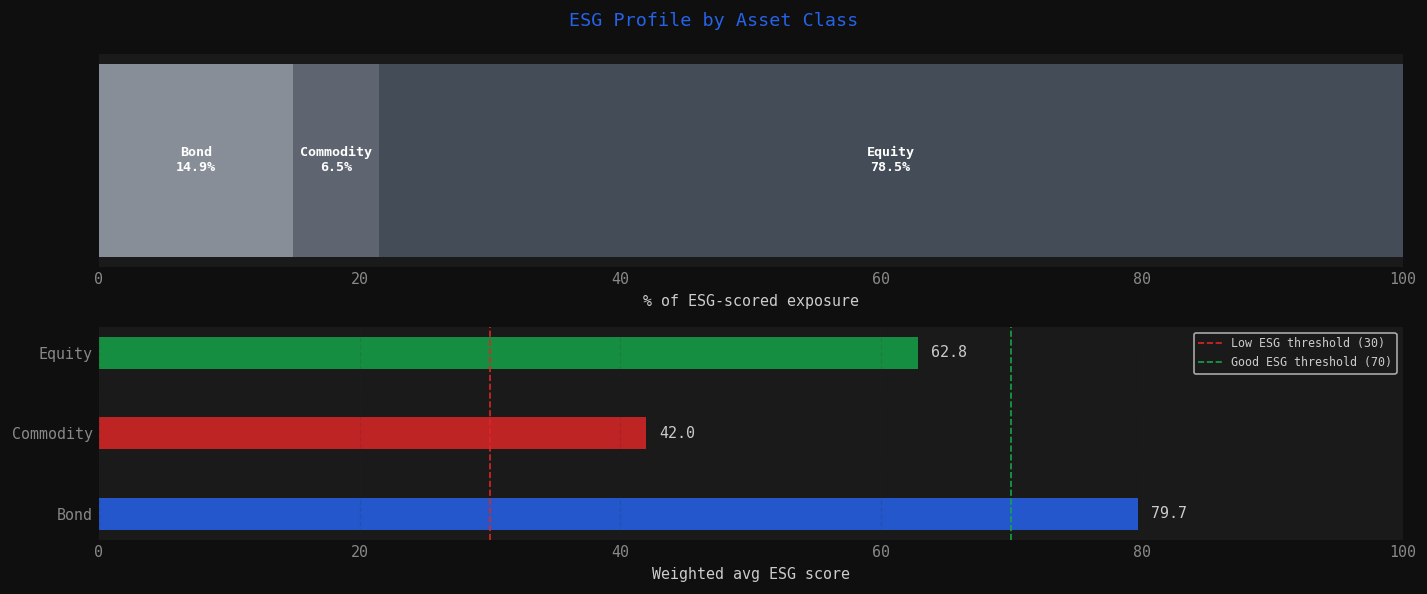

In [29]:
esg_scored = esg_df[esg_df['esg_score'].notna()].copy()
total_scored_mv = esg_scored['esg_exposure_eur'].sum()
ac_esg = esg_scored.groupby('asset_class').agg(
    wav_esg=('esg_score', lambda x: (x * esg_scored.loc[x.index, 'esg_exposure_eur']).sum() /
             esg_scored.loc[x.index, 'esg_exposure_eur'].sum()),
    exposure=('esg_exposure_eur', 'sum')
).reset_index()
ac_esg['pct_total'] = ac_esg['exposure'] / total_scored_mv * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
fig.suptitle('ESG Profile by Asset Class', color=ACCENT, fontsize=11)

colors = ['#9ca3af', '#6b7280', '#4b5563', '#374151', '#d1d5db', '#e5e7eb']
left = 0
for i, (_, row) in enumerate(ac_esg.iterrows()):
    axes[0].barh(0, row['pct_total'], left=left,
                 color=colors[i % len(colors)], alpha=0.85, height=0.4)
    if row['pct_total'] > 3:
        axes[0].text(left + row['pct_total']/2, 0,
                     f"{row['asset_class']}\n{row['pct_total']:.1f}%",
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    left += row['pct_total']

axes[0].set_xlim(0, 100)
axes[0].set_yticks([])
axes[0].set_xlabel('% of ESG-scored exposure', fontsize=9)
axes[0].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[0].tick_params(labelsize=9, length=0)

bars = axes[1].barh(ac_esg['asset_class'], ac_esg['wav_esg'],
                    color=[ACCENT2 if v < 50 else ACCENT3 if v < 70 else ACCENT
                           for v in ac_esg['wav_esg']],
                    height=0.4, alpha=0.85)
axes[1].axvline(ESG_THRESHOLD, color=ACCENT2, lw=1, linestyle='--',
                label=f'Low ESG threshold ({ESG_THRESHOLD})')
axes[1].axvline(70, color=ACCENT3, lw=1, linestyle='--', label='Good ESG threshold (70)')
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Weighted avg ESG score', fontsize=9)
axes[1].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
axes[1].grid(True, axis='x', alpha=0.15, linestyle='--')
axes[1].tick_params(labelsize=9, length=0)
axes[1].legend(fontsize=7)
for bar, val in zip(bars, ac_esg['wav_esg']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()